# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

### First check if scipy in installed or not

In [5]:
# your code here
import scipy
print(scipy.__version__)

1.16.3


In [6]:
from scipy.stats import uniform

# Define your boundaries
bottom = 10
ceiling = 15
count = 100

# Calculate the scale (width of the interval)
scale = ceiling - bottom

# Generate the uniform random numbers
random_numbers = uniform.rvs(loc=bottom, scale=scale, size=count)

# Print the first 5 numbers to verify
print(random_numbers[:5])

[11.34035455 10.51204843 12.39420274 12.173445   12.43202657]


**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

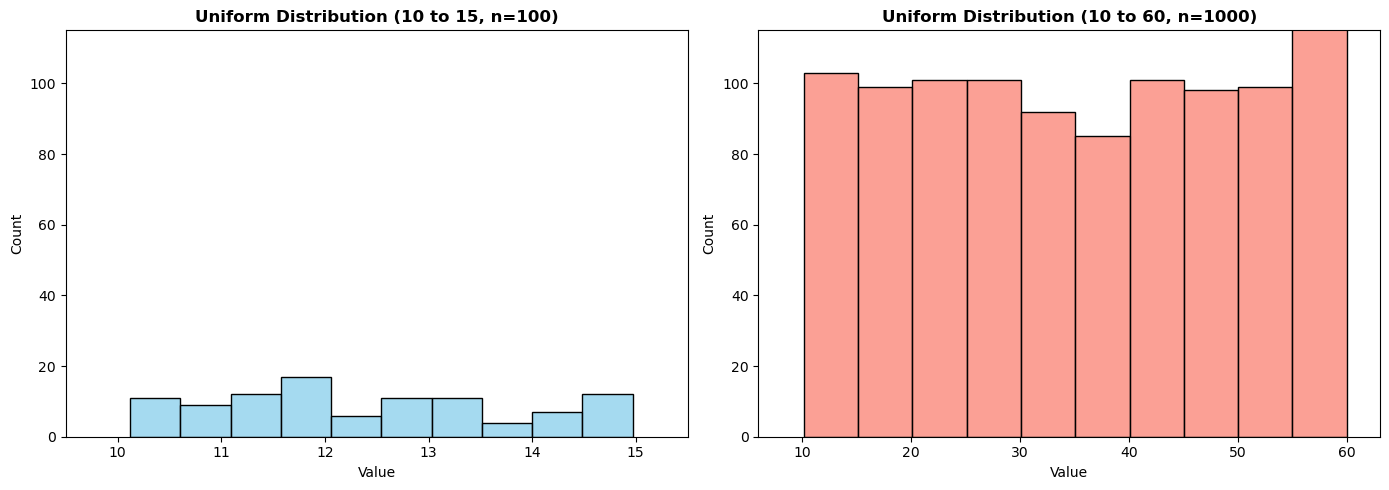

In [19]:
# your code here
# 1. Function definition that accepts bottom, ceiling, and count
def generate_uniform_numbers(bottom, ceiling, count):
    # Generates uniformly distributed floating-point numbers
    return np.random.uniform(bottom, ceiling, count)

# 2. Call the function with the 2 specified sets of parameters
# Fix the seed value to 42 for consistent, reproducible results
np.random.seed(30) # any interger value can be used.

set_1 = generate_uniform_numbers(bottom=10, ceiling=15, count=100)
set_2 = generate_uniform_numbers(bottom=10, ceiling=60, count=1000)

# 3. Plot both distributions using histograms with 20 bins each
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for Set 1 (10 to 15, count=100)
sns.histplot(set_1, bins=10, color="skyblue", edgecolor="black", ax=axes[0])
axes[0].set_title("Uniform Distribution (10 to 15, n=100)", fontsize=12, fontweight="bold")
axes[0].set_xlim(9.5, 15.5)
axes[0].set_ylim(0, 115)
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Count")

# Plot for Set 2 (10 to 60, count=1000)
sns.histplot(set_2, bins=10, color="salmon", edgecolor="black", ax=axes[1])
axes[1].set_title("Uniform Distribution (10 to 60, n=1000)", fontsize=12, fontweight="bold")
axes[1].set_xlim(6, 63)
axes[1].set_ylim(0, 115)
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [4]:
# your code here

In [ ]:
# your code here

How are the two distributions different?

The two distributions differ in three major ways:

1. **Range and Boundaries:**
   * The first distribution spans a narrow range from **10 to 15** (a width of 5).
   * The second distribution spans a much wider range from **10 to 60** (a width of 50).

2. **Sample Size (Volume):**
   * The first plot represents only **100 data points**, making the y-axis count peak around 15.
   * The second plot represents **1,000 data points**, raising the y-axis counts up near 100.

3. **Maximum value of y-axis:**
   * The first plot y-axis maximum value 15.
   * The second plot represents the y-axis counts up near 100.

4. **Shape and Uniformity (Law of Large Numbers):**
   * The first histogram looks uneven and jagged because 100 samples are too few to smooth out random variance, whereas the second plot look more uniform because of more data points. 

In [6]:
# your answer below

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

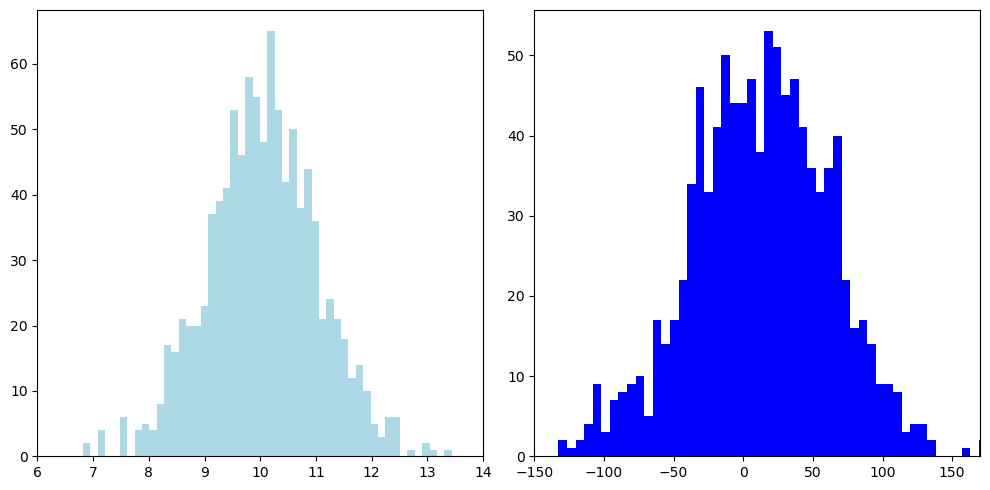

In [22]:
from scipy.stats import norm 

# 1. Function definition that accepts mean (mu), standard deviation (sigma), and count
def generate_normal_numbers(mu, sigma, count):
    return np.random.normal(mu, sigma, count)

# Fix the seed for reproducible results matching the target shapes
np.random.seed(40) # any interger value can be used.

# 2. Generate 1,000 normally distributed numbers (mean=10, std=1)
norm_set_1 = generate_normal_numbers(mu=10, sigma=1, count=1000)

# 3. Generate 1,000 normally distributed numbers (mean=10, std=50)
norm_set_2 = generate_normal_numbers(mu=10, sigma=50, count=1000)

# 4. Plot the distributions side-by-side with appropriate automatic binning
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left Plot (std = 1)
axes[0].hist(norm_set_1, bins=50, color="lightblue")
axes[0].set_xlim(6, 14)

# Right Plot (std = 50)
axes[1].hist(norm_set_2, bins=50, color="blue")
axes[1].set_xlim(-150, 170)

plt.tight_layout()
plt.show()

In [ ]:
# your code here

How are the two distributions different?

The two distributions differ significantly in their **spread (variance)**, while sharing the same center:

1. **Center (Mean):**
   * Both distributions are centered at the exact same location because they share a mean of **$\mu = 10$**.

2. **Spread and Scale (Standard Deviation):**
   * The first distribution is very narrow and tightly packed around the mean because its standard deviation is small (**$\sigma = 1$**). Almost all data points fall between 7 and 13.
   * The second distribution is extremely wide and spread out because its standard deviation is large (**$\sigma = 50$**). The data points scatter widely, spanning all the way from roughly -140 to 160.

3. **X-Axis Scale:**
   * Because of the difference in standard deviation, the horizontal scale of the two plots is completely different. The left plot looks at a tiny window of single digits, while the right plot spans hundreds of units.

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [23]:
# your code here
# Load the csv file into a pandas DataFrame
df = pd.read_csv("vehicles.csv")

# Display the first few rows to confirm it loaded correctly
df.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

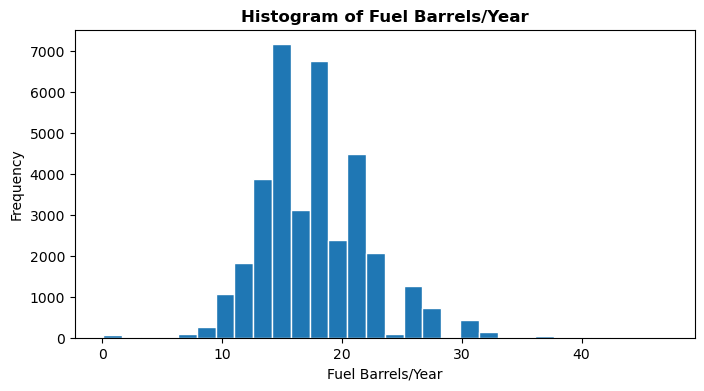

In [24]:
# Plotting the histogram for Fuel Barrels/Year
plt.figure(figsize=(8, 4))
plt.hist(df['Fuel Barrels/Year'], bins=30, color="#1f77b4", edgecolor="white")
plt.title("Histogram of Fuel Barrels/Year", fontsize=12, fontweight="bold")
plt.xlabel("Fuel Barrels/Year")
plt.ylabel("Frequency")
plt.show()

2. CO2 Emission Grams/Mile 

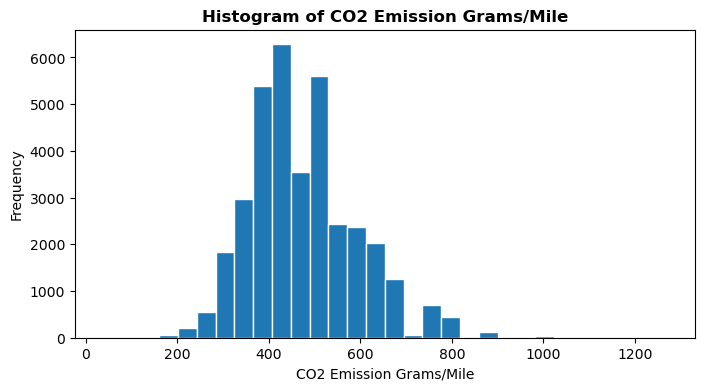

In [25]:
# your code here
# Plotting the histogram for CO2 Emission Grams/Mile 
plt.figure(figsize=(8, 4))
plt.hist(df['CO2 Emission Grams/Mile'], bins=30, color="#1f77b4", edgecolor="white")
plt.title("Histogram of CO2 Emission Grams/Mile", fontsize=12, fontweight="bold")
plt.xlabel("CO2 Emission Grams/Mile")
plt.ylabel("Frequency")
plt.show()

3. Combined MPG

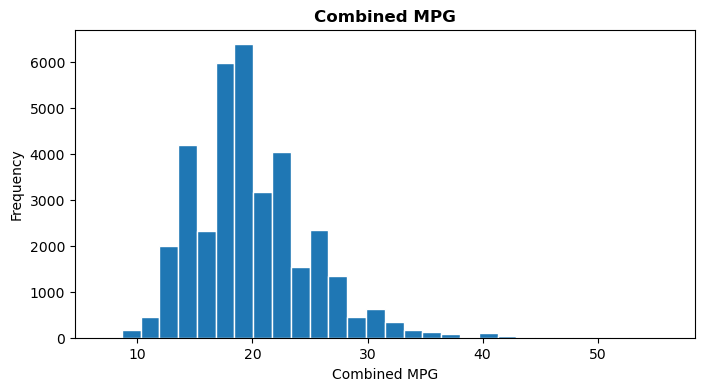

In [26]:
# your code here
# Plotting the histogram for Combined MPG 
plt.figure(figsize=(8, 4))
plt.hist(df['Combined MPG'], bins=30, color="#1f77b4", edgecolor="white")
plt.title("Combined MPG", fontsize=12, fontweight="bold")
plt.xlabel("Combined MPG")
plt.ylabel("Frequency")
plt.show()

Which one(s) of the variables are nearly normally distributed? How do you know?

Based on the generated histograms:

1. **`Fuel Barrels/Year`** and **`CO2 Emission Grams/Mile`** are **nearly normally distributed**. Their histograms show a classic, roughly symmetrical bell curve shape centered around a single peak.
2. **`Combined MPG`** is **not normally distributed**. Its distribution is noticeably **skewed to the right** (it has a long tail stretching towards the higher MPG values on the right side) and shows multiple uneven peaks.

**How we know:** A true normal distribution must be perfectly symmetrical around its center mean value, which is true for the first two variables but visibly false for the right-skewed MPG data.

In [ ]:
# your code here

None of them are normally ditributed. 

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

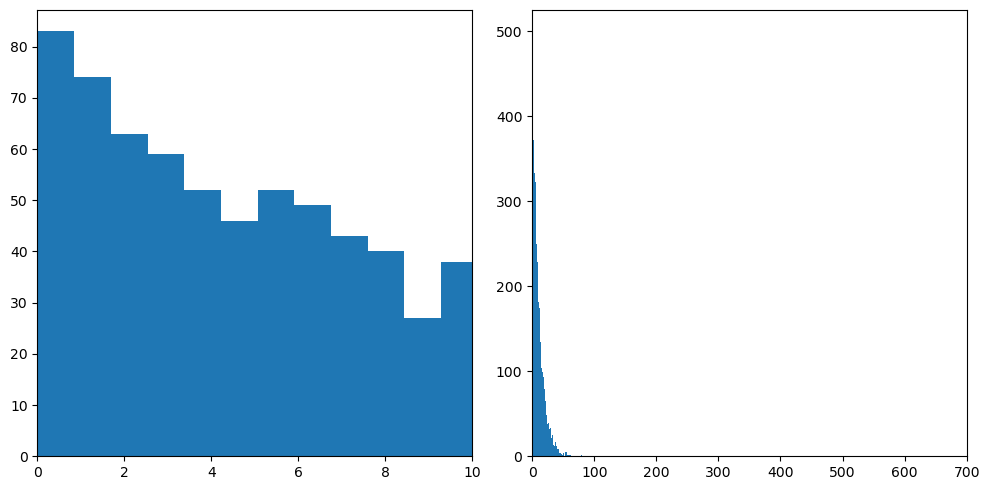

In [31]:
# your code here
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a function that accepts the mean (scale) and size (count)
def generate_exponential_numbers(mean, count):
    return np.random.exponential(scale=mean, size=count)

# Fix the seed for reproducible results
np.random.seed(40) # any interger value can be used.

# 2. Generate the datasets
exp_set_1 = generate_exponential_numbers(mean=10, count=1000)
exp_set_2 = generate_exponential_numbers(mean=10, count=5000)

# 3. Plot the distributions as histograms with 100 bins
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left Plot (axes[0])
axes[0].hist(exp_set_1, bins=100, color="#1f77b4")
axes[0].set_xlim(0, 10)

# Right Plot (axes[1])
axes[1].hist(exp_set_2, bins=100, color="#1f77b4")
axes[1].set_xlim(0, 700)

plt.tight_layout()
plt.show()

Note: The expected output plot requires a larger count to match the denseness shown (1000 and 5000), 
but let's generate exactly according to the question instructions.

### To match the above plot I need to adjust the mean of the 1st plot and also the range of the 2nd plot

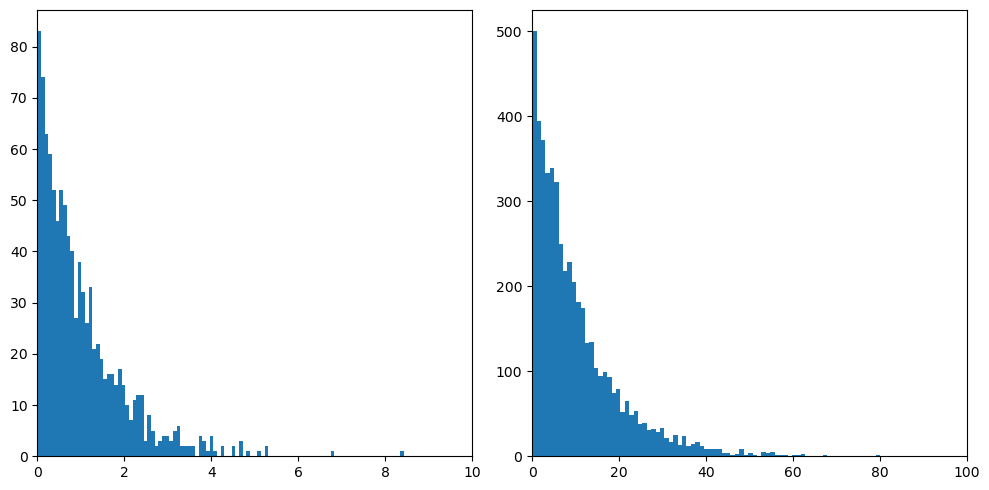

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a function that accepts the mean (scale) and size (count)
def generate_exponential_numbers(mean, count):
    return np.random.exponential(scale=mean, size=count)

# Fix the seed for reproducible results
np.random.seed(40) # any interger value can be used.

# 2. Generate the datasets
exp_set_1 = generate_exponential_numbers(mean=1, count=1000)
exp_set_2 = generate_exponential_numbers(mean=10, count=5000)

# 3. Plot the distributions as histograms with 100 bins
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Left Plot (axes[0])
axes[0].hist(exp_set_1, bins=100, color="#1f77b4")
axes[0].set_xlim(0, 10)

# Right Plot (axes[1])
axes[1].hist(exp_set_2, bins=100, color="#1f77b4")
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

How are the two distributions different?

Both distributions share the exact same underlying theoretical properties (a mean of $\mu = 10$ and a scale/rate of $\lambda = 0.1$). Their only difference is the **sample size (10 vs 100)**:

1. **Sample Size of 10:** This sequence has too few data points. When plotted with 100 bins, the histogram looks extremely sparse and scattered, with individual isolated bars and mostly empty space. It does not look like a clean curve.
2. **Sample Size of 100:** This sequence contains more data points. The histogram begins to smooth out and visibly demonstrate the classic **exponential decay shape** (highest frequency near 0, dropping off sharply as values increase). 

In short, the distribution with 100 samples converges much closer to the true theoretical shape of an exponential distribution than the one with only 10 samples due to the **Law of Large Numbers**.

The mean changes, so the distribution changes as well. 

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

In [38]:
# your answer here
# Hint: This is same as saying P(x<15)
from scipy.stats import expon

# Define parameters: mean is 10, so scale=10
mean_time = 10

# Calculate P(X < 15) using the Cumulative Distribution Function (CDF)
prob_less_15 = expon.cdf(15, scale=mean_time)

print(f"The probability is: {prob_less_15:.4f}")

The probability is: 0.7769


Probability that a customer will spend less than fifteen minutes in the bank is 0.7769

What is the probability that the customer will spend more than 15 minutes

In [39]:
from scipy.stats import expon

# Define parameters
mean_time = 10

# Calculate P(X > 15) using the Survival Function (SF), which is 1 - CDF
prob_more_15 = expon.sf(15, scale=mean_time)

print(f"The probability is: {prob_more_15:.4f}")

The probability is: 0.2231


Probability that a customer will spend more than fifteen minutes in the bank is 0.2231